# Model 8: Bounded Hebbian Learning

## Question

How do we preserve Hebbian learning while preventing runaway synaptic strength?

The biggest limitation of Model 7 is that it exhibits unbounded growth. As long as the pre- and postsynaptic neurons continue to be active together, the connection strength will continue to grow without an upper bound.

## Solution

This limitation can be addressed by introducing a mechanism in which the amount of strengthening diminishes as the connections grows stronger.

Instead of using the equation:

Δw = ηxy

we use the equation:

Δw = ηxy(1 - w)

to get a curve that approaches a horizaontal asymptote.

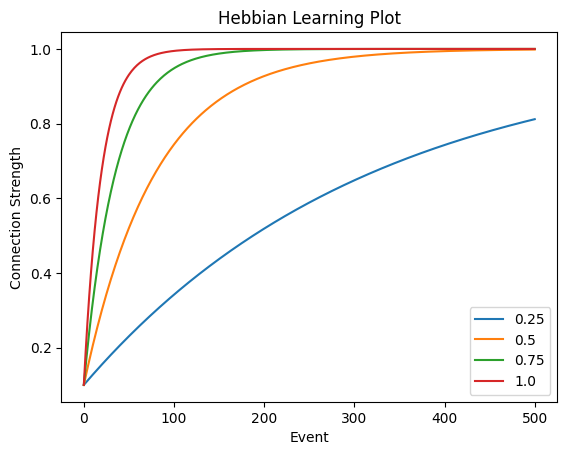

In [4]:
import numpy as np
import matplotlib.pyplot as plt

activity_levels = [0.25, 0.5, 0.75, 1.0]

for activity_level in activity_levels:

    presynaptic_activity = postsynaptic_activity = activity_level

    connection_strength_initial = 0.1
    learning_rate = 0.05

    connection_strengths = [connection_strength_initial]
    events = [0]

    for i in range(1, 501):
        connection_strength_final = connection_strength_initial + learning_rate * presynaptic_activity * postsynaptic_activity * (1 - connection_strength_initial)
        connection_strength_initial = connection_strength_final
        connection_strengths.append(connection_strength_initial)
        events.append(i)

    label = f"{activity_level}"
    plt.plot(events, connection_strengths, label=label)

        
plt.xlabel("Event")
plt.ylabel("Connection Strength")
plt.title("Hebbian Learning Plot")
plt.legend()
plt.show()

### Model 8 Interpretation

After implementing diminishing synaptic strengthening, we can see that, regardless of activity level, each connection strength eventually converges toward 1. Model 8 simulates 500 learning events and demonstrates that higher level of co-activity cause the connection strength to approach 1 more quickly.

### Model 8 Limitations

As long as x and y are positive and remain constant, every pair eventually reaches the same maximum connection strength of 1. Therefore, changes in activity level affect only the rate of learning, rather than the eventual learned connection strength.